# Differentiation

In [14]:
import os
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def h5_value_to_python(v):
    """
    Convert HDF5 attribute values to normal Python values.
    """
    if isinstance(v, bytes):
        return v.decode()

    if isinstance(v, np.generic):
        return v.item()

    if isinstance(v, np.ndarray):
        if v.shape == ():
            return v.item()
        return v.tolist()

    return v

import json
import os


def flatten_dict(d, parent_key="", sep="."):
    out = {}

    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k

        if isinstance(v, dict):
            out.update(flatten_dict(v, new_key, sep=sep))
        else:
            out[new_key] = v

    return out


def read_json_parameters(sim_dir):
    """
    Read simulation parameters from the json file inside sim_dir.
    Ignores domain/time/grid parameters and keeps only model parameters.
    """

    json_files = [f for f in os.listdir(sim_dir) if f.endswith(".json")]

    if not json_files:
        return {}

    json_path = os.path.join(sim_dir, json_files[0])

    with open(json_path, "r") as f:
        config = json.load(f)

    params = {}

    # Keep bead parameters
    if "beads" in config:
        for k, v in config["beads"].items():
            params[k] = v
            # params[f"beads.{k}"] = v

    # Keep equation/model parameters
    if "params" in config:
        for k, v in config["params"].items():
            params[k] = v
            # params[f"params.{k}"] = v

    # Keep seed if useful
    if "ic" in config and "seed" in config["ic"]:
        params["seed"] = config["ic"]["seed"]

    return params



def read_simulation_parameters(f):
    """
    Read only simulation/model parameters from the HDF5 file.
    Ignores grid/domain metadata such as Nx, Ny, Lx, Ly.
    """

    metadata = {}

    groups_to_read = ["params", "beads"]

    for group_name in groups_to_read:
        if group_name not in f:
            continue

        group = f[group_name]

        for k, v in group.attrs.items():
            metadata[k] = h5_value_to_python(v)
            metadata[f"{group_name}.{k}"] = h5_value_to_python(v)

    return metadata


def standardize_metadata(metadata):
    """
    Optional: create short column names used by your plotting functions.

    Adjust this depending on how your metadata is saved.
    """

    aliases = {
        "beads.N_bd": "nb",
        "grid.Nbd": "nb",
        "Nbd": "nb",
        "Nb": "nb",

        "beads.m_bd": "rbm",
        "m_bd": "rbm",
        "rm": "rbm",

        "beads.sig_bd": "sig",
        "sig_bd": "sig",
        "sigma": "sig",

        "params.D_psi": "dpsi",
        "D_psi": "dpsi",
        "Dpsi": "dpsi",

        "params.rq": "rq",
        "params.v0": "v0",

        "beads.dist": "dist",
    }

    out = dict(metadata)

    for old, new in aliases.items():
        if old in out and new not in out:
            out[new] = out[old]

    return out


def analyze_h5(h5_path, t=-1):
    with h5py.File(h5_path, "r") as f:
        psi = f["solution/psi_hist"][t]

        if "solution/qx_hist" in f and "solution/qy_hist" in f:
            qx = f["solution/qx_hist"][t]
            qy = f["solution/qy_hist"][t]
            Nb = f["grid"].attrs["Nbd"]
            qmag = np.sqrt(qx**2 + qy**2)
            area_q = np.mean(qmag)
        else:
            area_q = np.nan
    f = lambda psi, rm, Dpsi: 0.25 * (psi ** 2 - 1) ** 2 - rm * psi * (1 - psi / 2) + Dpsi / 2 * (np.gradient(psi) ** 2)


    area_psi = round(np.mean(0.5 * (np.clip(psi, -1, 1) + 1)), 2)

    return {
        "Nb": Nb,
        "area_psi": area_psi,
        "area_q": area_q,
        "max_psi": np.max(psi),
        "has_diff": np.any(psi > 0.9),
    }


def scan(base_dir, t=-1):
    rows = []

    for root, dirs, files in os.walk(base_dir):
        h5_files = [f for f in files if f.endswith(".h5")]

        for h5_file in h5_files:
            h5_path = os.path.join(root, h5_file)

            try:
                obs = analyze_h5(h5_path, t=t)
            except Exception as e:
                print(f"Skipping {h5_path}: {e}")
                continue

            metadata = read_json_parameters(root)

            row = {
                "h5_path": h5_path,
                "sim_folder": os.path.basename(root),
                "param_folder": os.path.basename(os.path.dirname(root)),
            }

            row.update(metadata)
            row.update(obs)

            rows.append(row)

    return pd.DataFrame(rows)


def plot_area_vs_nb(df, rq, v0, y="area_psi"):
    # Filter dataset
    df_sub = df[(df["rq"] == rq) & (df["v0"] == v0)]

    if df_sub.empty:
        raise ValueError("No data for given rq and v0")

    # Group by number of beads
    grouped = df_sub.groupby("nb")[y].mean()

    # fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(
        grouped.index,
        grouped.values,
        "o-", 
        label=f"rq={rq}, v0={v0}"
    )

    # return fig, ax



def plot_vs(df, xparam, y="area_psi"):
    grouped = df.groupby(xparam)[y]

    mean = grouped.mean()
    std = grouped.std()

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.errorbar(
        mean.index,
        mean.values,
        yerr=std.values,
        fmt="o-",
        capsize=3,
    )

    ax.set_xlabel(xparam)
    ax.set_ylabel(y)
    ax.grid()
    ax.set_ylim(-0.1, 1.1)

    return fig, ax


def print_available_parameters(df):
    """
    Print unique values available for each parameter column.
    """

    # Columns you want to ignore
    ignore = {
        "param_folder",
        "sim_folder",
        "h5_path",
        "area_psi",
        "area_q",
        "max_psi",
        "has_diff",
        "diff",
    }

    # Candidate parameter columns
    param_cols = [c for c in df.columns if c not in ignore]

    print("=" * 50)

    for col in sorted(param_cols):

        # Remove NaNs and sort values
        vals = sorted(df[col].dropna().unique())

        print(f"{col}:")
        print(vals)
        print()

    print("=" * 50)



def plot_binary_phase_scatter(df, x, y, fixed=None, ax=None):
    """
    Binary phase diagram using scatter points.

    diff = True  -> differentiated
    diff = False -> not differentiated
    """

    d = df.copy()

    # Apply fixed parameter filters
    if fixed is not None:
        for k, v in fixed.items():
            d = d[d[k] == v]

    if d.empty:
        raise ValueError("No data after filtering")

    # Separate differentiated / non differentiated
    d_true = d[d["has_diff"] == True]
    d_false = d[d["has_diff"] == False]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    # Differentiated
    from matplotlib.colors import LogNorm

    cvals = d_true["area_psi"].values

    # avoid non-positive values for log scale by finding smallest positive value
    positive = cvals[cvals > 0]
    if positive.size >= 0:
        vmin = positive.min()
    else:
        vmin = 1e-6

    vmax = max(cvals.max(), vmin)
    # norm = LogNorm(vmin=vmin, vmax=1)

    # Non differentiated
    ax.scatter(
        d_false[x],
        d_false[y],
        marker="x",
        s=80,
        color="red",
        label="No differentiation"
    )

    # Differentiated
    cm = ax.scatter(
        d_true[x],
        d_true[y],
        marker="o",
        s=80,
        label="Differentiated",
        c=cvals,
        cmap="viridis"
        # norm=norm,
    )


    cbar = fig.colorbar(cm, ax=ax)
    cbar.set_label("Area of psi")
    if fixed is not None:
        title = ", ".join([f"{k}={v}" for k, v in fixed.items()])
        ax.set_title(title)

    ax.grid()
    # ax.legend()

    return fig, ax

# Beads no dynamics

In [15]:
base_dir = "outputs/differentiation_sweep/"

df = scan(base_dir)

display(df)

print_available_parameters(df)

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

df.to_csv("memory_models.differentiation_sweep")

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,h5_path,sim_folder,param_folder,type,rbm,x0,y0,sigma,t_dec,dist,...,alpha,rq,mu,dpsi,seed,Nb,area_psi,area_q,max_psi,has_diff
0,outputs/differentiation_sweep/dist_pol_sig_0.5...,sim_data_20260601_164419,dist_pol_sig_0.5_rbm_0.1_x0_25.0_dpsi_1.0,pol,0.1,25.0,25.0,0.5,50.0,pol,...,0.0,0.0,1.0,1.0,1355631916,0.157080,0.00,0.0,-1.0,False
1,outputs/differentiation_sweep/dist_pol_sig_0.5...,sim_data_20260609_113852,dist_pol_sig_0.5_rbm_0.1_x0_25.0_dpsi_1.0,pol,0.1,25.0,25.0,0.5,50.0,pol,...,0.0,0.0,1.0,NaN,1276789456,0.157080,0.00,0.0,-1.0,False
2,outputs/differentiation_sweep/dist_pol_sig_4.0...,sim_data_20260605_063046,dist_pol_sig_4.0_rbm_0.9_x0_25.0_dpsi_20.0,pol,0.9,25.0,25.0,4.0,50.0,pol,...,0.0,0.0,1.0,20.0,961637054,90.477868,0.00,0.0,-1.0,False
3,outputs/differentiation_sweep/dist_pol_sig_20....,sim_data_20260603_114028,dist_pol_sig_20.0_rbm_0.5_x0_25.0_dpsi_1.0,pol,0.5,25.0,25.0,20.0,50.0,pol,...,0.0,0.0,1.0,1.0,470971399,781.660305,1.00,0.0,1.0,True
4,outputs/differentiation_sweep/dist_pol_sig_25....,sim_data_20260603_120127,dist_pol_sig_25.0_rbm_0.9_x0_25.0_dpsi_3.0,pol,0.9,25.0,25.0,25.0,50.0,pol,...,0.0,0.0,1.0,3.0,174599931,1647.161963,1.00,0.0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271,outputs/differentiation_sweep/dist_pol_sig_5.0...,sim_data_20260605_092014,dist_pol_sig_5.0_rbm_0.4_x0_25.0_dpsi_10.0,pol,0.4,25.0,25.0,5.0,50.0,pol,...,0.0,0.0,1.0,10.0,1436015159,62.831781,0.00,0.0,-1.0,False
2272,outputs/differentiation_sweep/dist_pol_sig_4.5...,sim_data_20260605_072009,dist_pol_sig_4.5_rbm_0.4_x0_25.0_dpsi_7.0,pol,0.4,25.0,25.0,4.5,50.0,pol,...,0.0,0.0,1.0,7.0,2024277774,50.893798,0.00,0.0,-1.0,False
2273,outputs/differentiation_sweep/dist_pol_sig_20_...,sim_data_20260521_172411,dist_pol_sig_20_rbm_0.7_x0_25.0_dpsi_5.0,pol,0.7,25.0,25.0,20.0,50.0,pol,...,0.0,0.0,1.0,5.0,1790479908,1094.324427,1.00,0.0,1.0,True
2274,outputs/differentiation_sweep/dist_pol_sig_3.5...,sim_data_20260605_034611,dist_pol_sig_3.5_rbm_0.5_x0_25.0_dpsi_10.0,pol,0.5,25.0,25.0,3.5,50.0,pol,...,0.0,0.0,1.0,10.0,1682758103,38.484510,0.00,0.0,-1.0,False


D_p:
[np.float64(0.1), np.float64(1.0)]

D_psi:
[np.float64(0.1), np.float64(1.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(25.0), np.float64(30.0)]

Nb:
[np.float64(0.15707963267948966), np.float64(0.3141592653589793), np.float64(0.47123889803846897), np.float64(0.6283185307179586), np.float64(0.7853981633974483), np.float64(0.7853981633974484), np.float64(0.9424777960769379), np.float64(0.942477806162536), np.float64(1.0995574287564274), np.float64(1.0995574287564276), np.float64(1.099557440522959), np.float64(1.2566370614359172), np.float64(1.2566370748833815), np.float64(1.4137166941154071), np.float64(1.4137167092438045), np.float64(1.5707963267948966), np.float64(1.5707963267948968), np.float64(1.5707963436042267), np.float64(1.8849555921538756), np.float64(1.8849555921538759), np.float64(2.5132741228718345), np.float64(2.513274122871835), np.float64(2.8274333882308142), np.float64(3.141592653589793), np.f

In [16]:
from scipy.integrate import quad


def f(psi, rm):
    output = (0.25 * (psi**2 - 1)**2 - rm * psi * (1 - psi/2))
    return output

def integrand(psi, rm):
            return np.sqrt(np.abs(f(psi, rm)))


rc = 0.25
rm_arr = np.linspace(0.0, 1.0, 100)

def compute_sig_teo(rm_arr, rc, D):
    sig_arr = []

    for rm in rm_arr:
        integral, _ = quad(integrand, -1, 1, args=(rm,))
        aux = np.sqrt(D) * integral / (rm * np.log(rm / rc) ** (1/2))
        sig_arr.append(aux)
    return np.array(sig_arr)

/tmp/ipykernel_43747/4086930683.py:20: RuntimeWarning: divide by zero encountered in log
  aux = np.sqrt(D) * integral / (rm * np.log(rm / rc) ** (1/2))
/tmp/ipykernel_43747/4086930683.py:20: RuntimeWarning: invalid value encountered in scalar multiply
  aux = np.sqrt(D) * integral / (rm * np.log(rm / rc) ** (1/2))
/tmp/ipykernel_43747/4086930683.py:20: RuntimeWarning: invalid value encountered in scalar power
  aux = np.sqrt(D) * integral / (rm * np.log(rm / rc) ** (1/2))


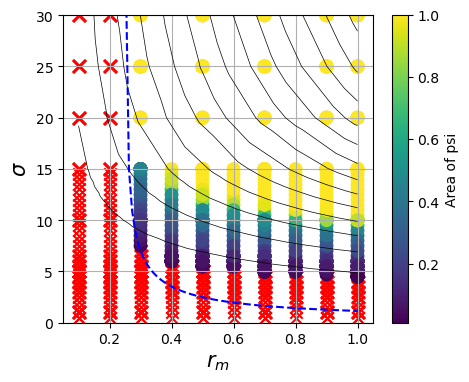

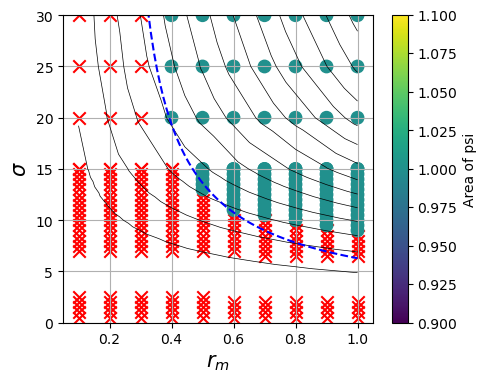

In [17]:
fixed = {
        "D_psi": 1.0,
        }

fig, ax = plt.subplots(figsize=(5, 4))
plot_binary_phase_scatter(
    df,
    x="rbm",
    y="sigma",
    fixed=fixed,
    ax=ax
)

d = df.copy()
d=d[d["x0"] == 25.0]
sig = d["sigma"].values
rbm = d["rbm"].values
Nb = d["Nb"].values
ax.tricontour(rbm, sig, Nb, levels=14, linewidths=0.5, colors='k')
plt.xlim(0.05, 1.05)
plt.ylim(0.0, 30.05)
ax.set_xlabel(r"$r_m$", fontsize=15)
ax.set_ylabel(r"$\sigma$", fontsize=15)
plt.title("")
plt.savefig("phase_diagram_gauss_dpsi_1.png", dpi=300, bbox_inches="tight")


sig_arr = compute_sig_teo(rm_arr, rc, 1.0)
ax.plot(rm_arr, sig_arr, 'b--', label='Analytical Transition Curve')

# add_binary_transition_curve(ax, df, fixed, x="rbm", y="sigma", eps=1e-2, value="area_psi")


fixed = {
        "D_psi": 30.0,
        }

fig, ax = plt.subplots(figsize=(5, 4))
plot_binary_phase_scatter(
    df,
    x="rbm",
    y="sigma",
    fixed=fixed,
    ax=ax
)

d = df.copy()
d=d[d["x0"] == 25.0]
sig = d["sigma"].values
rbm = d["rbm"].values
Nb = d["Nb"].values
ax.tricontour(rbm, sig, Nb, levels=14, linewidths=0.5, colors='k')
plt.xlim(0.05, 1.05)
plt.ylim(0.0, 30.05)
ax.set_xlabel(r"$r_m$", fontsize=15)
ax.set_ylabel(r"$\sigma$", fontsize=15)
plt.title("")

sig_arr = compute_sig_teo(rm_arr, rc, 30.0)
ax.plot(rm_arr, sig_arr, 'b--', label='Analytical Transition Curve')

# add_binary_transition_curve(ax, df, fixed, x="rbm", y="sigma", eps=1e-2, value="area_psi")
plt.savefig("phase_diagram_gauss_dpsi_30.png", dpi=300, bbox_inches="tight")


# Dynamics

In [18]:
base_dir = "outputs/dyn_gauss"

df = scan(base_dir)
display(df)

print_available_parameters(df)

def plot_vs_fixed(df, xparam, fixed=None, y="area_psi", ax=None):
    """
    Plot mean y versus xparam, fixing arbitrary parameters.

    Example:
    plot_vs_fixed(df, "nb", fixed={"rq": 1.0, "v0": 3.0})
    """

    if fixed is None:
        fixed = {}

    df_sub = df.copy()

    for key, value in fixed.items():
        df_sub = df_sub[df_sub[key] == value]

    if df_sub.empty:
        raise ValueError(f"No data for fixed parameters: {fixed}")

    grouped = df_sub.groupby(xparam)[y].mean().sort_index()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    label = ", ".join([f"{k}={v}" for k, v in fixed.items()])

    ax.plot(
        grouped.index,
        grouped.values,
        "o-",
        label=label
    )

    ax.set_xlabel("integral rb")
    ax.set_ylabel(y)
    ax.legend()

    return fig, ax


,h5_path,sim_folder,param_folder,type,rbm,x0,y0,sigma,t_dec,dist,...,alpha,rq,mu,dpsi,seed,Nb,area_psi,area_q,max_psi,has_diff
0,outputs/dyn_gauss/dist_pol_sig_30.0_rbm_0.5_x0...,sim_data_20260522_191842,dist_pol_sig_30.0_rbm_0.5_x0_25.0_dpsi_1.0_rq_...,pol,0.50,25.0,25.0,30.0,50.0,pol,...,0.5,0.5,1.0,1.00,615919479,1002.114964,1.00,0.968992,1.157277,True
1,outputs/dyn_gauss/dist_pol_sig_30.0_rbm_0.05_x...,sim_data_20260522_173453,dist_pol_sig_30.0_rbm_0.05_x0_25.0_dpsi_0.5_rq...,pol,0.05,25.0,25.0,30.0,50.0,pol,...,0.5,0.5,1.0,0.50,1792935153,100.211496,0.00,0.098601,-1.000000,False
2,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.05_x0_...,sim_data_20260522_153438,dist_pol_sig_10_rbm_0.05_x0_12.5_dpsi_1.0_rq_0...,pol,0.05,12.5,25.0,10.0,50.0,pol,...,0.5,0.0,1.0,1.00,1872945818,27.854400,0.00,0.013251,-1.000000,False
3,outputs/dyn_gauss/dist_pol_sig_30.0_rbm_0.05_x...,sim_data_20260522_173523,dist_pol_sig_30.0_rbm_0.05_x0_25.0_dpsi_1.0_rq...,pol,0.05,25.0,25.0,30.0,50.0,pol,...,0.5,0.5,1.0,1.00,1380324220,100.211496,0.00,0.101160,-1.000000,False
4,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.1_x0_1...,sim_data_20260522_155203,dist_pol_sig_10_rbm_0.1_x0_12.5_dpsi_1.0_rq_0....,pol,0.10,12.5,25.0,10.0,50.0,pol,...,0.5,0.0,1.0,1.00,1013528315,55.708800,0.00,0.047306,-1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,outputs/dyn_gauss/dist_pol_sig_30.0_rbm_0.2_x0...,sim_data_20260522_180951,dist_pol_sig_30.0_rbm_0.2_x0_25.0_dpsi_0.01_rq...,pol,0.20,25.0,25.0,30.0,50.0,pol,...,0.5,0.5,1.0,0.01,1706031818,400.845986,1.00,0.968983,1.142335,True
266,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.2_x0_1...,sim_data_20260522_160902,dist_pol_sig_10_rbm_0.2_x0_12.5_dpsi_0.01_rq_1...,pol,0.20,12.5,25.0,10.0,50.0,pol,...,0.5,1.0,1.0,0.01,1668763055,111.417601,0.56,0.681780,1.049905,True
267,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.5_x0_1...,sim_data_20260522_171722,dist_pol_sig_10_rbm_0.5_x0_12.5_dpsi_1.0_rq_0....,pol,0.50,12.5,25.0,10.0,50.0,pol,...,0.5,0.0,1.0,1.00,1405975358,278.544001,0.53,0.754542,1.053725,True
268,outputs/dyn_gauss/dist_pol_sig_10_rbm_0.5_x0_1...,sim_data_20260522_170113,dist_pol_sig_10_rbm_0.5_x0_12.5_dpsi_0.5_rq_1....,pol,0.50,12.5,25.0,10.0,50.0,pol,...,0.5,1.0,1.0,0.50,1924946237,278.544001,1.00,0.968207,1.053886,True


D_p:
[np.float64(1.0)]

D_psi:
[np.float64(1.0)]

Nb:
[np.float64(27.854400125655705), np.float64(55.70880025131141), np.float64(100.21149643777747), np.float64(111.41760050262282), np.float64(167.1264007539342), np.float64(200.42299287555494), np.float64(278.544001256557), np.float64(400.8459857511099), np.float64(601.2689786266649), np.float64(1002.1149643777746)]

alpha:
[np.float64(0.5)]

dist:
['pol']

dpsi:
[np.float64(0.01), np.float64(0.5), np.float64(1.0)]

gamma:
[np.float64(1.0)]

lam_p:
[np.float64(5.0)]

lam_psi:
[np.float64(1.0)]

mu:
[np.float64(1.0)]

rbm:
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.5)]

rq:
[np.float64(0.0), np.float64(0.5), np.float64(1.0)]

seed:
[np.int64(1406554), np.int64(2413353), np.int64(12958766), np.int64(24235043), np.int64(30875365), np.int64(35515385), np.int64(42839721), np.int64(44446831), np.int64(76920782), np.int64(102134021), np.int64(105197563), np.int64(105583971), np.int64(106082421), np.int6

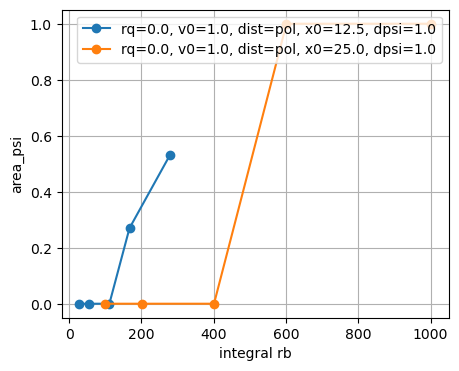

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))

fixed = {
        "rq": 0.0,
        "v0": 1.0,
        "dist": "pol",
        "x0": 12.5, 
        "dpsi": 1.0
        }

plot_vs_fixed(
    df,
    xparam="Nb",
    y="area_psi",
    fixed=fixed, 
    ax=ax
)

fixed["x0"] = 25.0

plot_vs_fixed(
    df,
    xparam="Nb",
    y="area_psi",
    fixed=fixed, 
    ax=ax
)
plt.grid()
# plt.xlim(0, 200)
plt.show()